In [1]:
import pandas as pd
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../"))
sys.path.append(project_root)
from src.model_trainer import ModelTrainer;

✅ Linear Regression processing complete.
✅ Lasso processing complete.
✅ Ridge processing complete.
✅ ElasticNet processing complete.
✅ KNN processing complete.
✅ Decision Tree processing complete.
✅ Random Forest processing complete.
✅ XGBoost processing complete.
✅ CatBoost processing complete.
✅ AdaBoost processing complete.
✅ Gradient Boosting processing complete.
✅ SVR processing complete.

🏆 FINAL PERFORMANCE METRICS FOR ALL MODELS


,Model,R2 Score,RMSE,MAE
8,CatBoost,0.538922,1.753420,1.038310
6,Random Forest,0.533571,1.763565,1.008400
1,Lasso,0.525887,1.778032,1.016855
10,Gradient Boosting,0.523280,1.782912,1.068083
9,AdaBoost,0.513848,1.800465,1.110112
3,ElasticNet,0.509882,1.807793,1.037481
7,XGBoost,0.497980,1.829612,1.038432
0,Linear Regression,0.495220,1.834634,1.025883
2,Ridge,0.495149,1.834763,1.026078
5,Decision Tree,0.414964,1.975104,1.240513


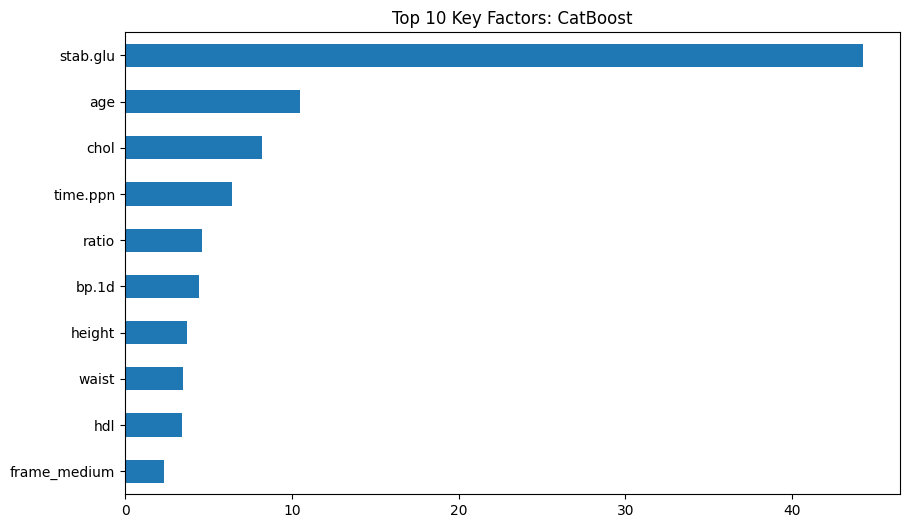

In [2]:

# Load the transformed features
X_train_final = pd.read_csv("../data/Transformed/X_train_transformed.csv")
X_test_final = pd.read_csv("../data/Transformed/X_test_transformed.csv")

# Load the original targets (from the splitted folder)
y_train = pd.read_csv("../data/Preprocessing/splitted/y_train.csv")
y_test = pd.read_csv("../data/Preprocessing/splitted/y_test.csv")
# Initialize# Initialize the trainer
reg_trainer = ModelTrainer(task_type='regression')

# Run the training and CAPTURE the dataframe
results_df = reg_trainer.train_and_evaluate(X_train_final, X_test_final, y_train, y_test)

# --- DISPLAY THE TABLE ---
print("\n" + "="*50)
print("🏆 FINAL PERFORMANCE METRICS FOR ALL MODELS")
print("="*50)
display(results_df) 

# --- PLOT THE BEST MODEL (Answers RQ2) ---
best_model = results_df.iloc[0]['Model']
reg_trainer.plot_importance(best_model, X_train_final.columns)

✅ Logistic Regression processing complete.
✅ KNN processing complete.
✅ Decision Tree processing complete.
✅ Random Forest processing complete.
✅ XGBoost processing complete.


c:\Users\Birhanu Matebe\Desktop\ML\Ml\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:29:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ CatBoost processing complete.
✅ AdaBoost processing complete.
✅ Gradient Boosting processing complete.
✅ SVM processing complete.


,Model,Accuracy,F1 Score,Recall
1,KNN,0.884615,0.640000,0.5000
3,Random Forest,0.884615,0.640000,0.5000
4,XGBoost,0.884615,0.640000,0.5000
5,CatBoost,0.884615,0.640000,0.5000
6,AdaBoost,0.884615,0.640000,0.5000
8,SVM,0.884615,0.640000,0.5000
7,Gradient Boosting,0.871795,0.615385,0.5000
2,Decision Tree,0.858974,0.592593,0.5000
0,Logistic Regression,0.871795,0.583333,0.4375


📈 Plotting Risk Factors using the best compatible model: Random Forest


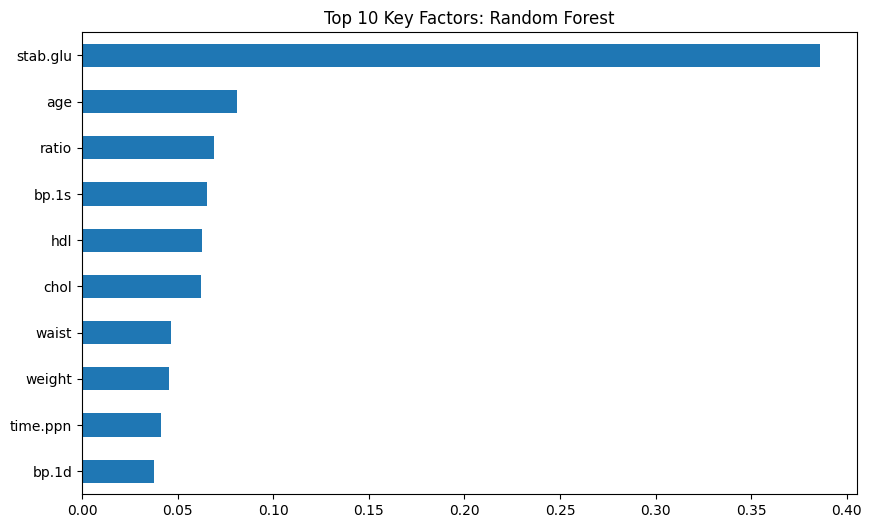

In [4]:
# 1. Prepare binary labels
y_train_class = (y_train >= 6.5).astype(int)
y_test_class = (y_test >= 6.5).astype(int)

# 2. Initialize and Run Classification
clf_trainer = ModelTrainer(task_type='classification')
q2_results = clf_trainer.train_and_evaluate(X_train_final, X_test_final, y_train_class, y_test_class)

# 3. DISPLAY THE TABLE
from IPython.display import display
display(q2_results)

# 4. PLOT FEATURE IMPORTANCE
# We check the top models to find one that supports plotting (Random Forest, XGBoost, etc.)
# If the #1 model is KNN, we move to the #2 model, and so on.

for i in range(len(q2_results)):
    best_clf_model = q2_results.iloc[i]['Model']
    # These models in your class support importance:
    plot_support = ["Decision Tree", "Random Forest", "XGBoost", "CatBoost", "AdaBoost", "Gradient Boosting"]
    
    if best_clf_model in plot_support:
        print(f"📈 Plotting Risk Factors using the best compatible model: {best_clf_model}")
        clf_trainer.plot_importance(best_clf_model, X_train_final.columns)
        break